# Modèle 3 — XGBoost (Gradient Boosting)

## Qu'est-ce que XGBoost ?
XGBoost (Extreme Gradient Boosting) est un algorithme de boosting.
Contrairement au Random Forest qui construit les arbres en parallèle,
XGBoost les construit **séquentiellement** — chaque arbre corrige 
les erreurs du précédent.

## Pourquoi XGBoost ?
- Souvent le meilleur modèle sur les données tabulaires
- Gère nativement le déséquilibre des classes
- Plus rapide que Random Forest grâce à l'optimisation
- Régularisation intégrée contre le surapprentissage

## Différence avec Random Forest
| | Random Forest | XGBoost |
|---|---|---|
| Construction | Arbres en parallèle | Arbres séquentiels |
| Apprentissage | Indépendant | Corrige les erreurs |
| Vitesse | Plus lent | Plus rapide |
| Performance | Bonne | Souvent meilleure |

## Tâches
- **Tâche 1** : Classification — prédire `churn` (0/1)
- **Tâche 2** : Régression — prédire `revenue_at_risk`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, mean_absolute_error,
    mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


## Chargement des données preprocessées

Mêmes données que les modèles précédents.
On charge les fichiers .npy générés par le preprocessing.

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

y_train_reg = np.load('../data/processed/y_train_reg.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

# Calcul du ratio pour gérer le déséquilibre
neg = (y_train_clf == 0).sum()
pos = (y_train_clf == 1).sum()
scale_pos_weight = neg / pos

print(f"Données chargées")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Ratio négatifs/positifs : {scale_pos_weight:.1f}")
print(f"   → scale_pos_weight = {scale_pos_weight:.1f}")

Données chargées
   X_train : (8000, 51)
   X_test  : (2000, 51)
   Ratio négatifs/positifs : 8.8
   → scale_pos_weight = 8.8


## Tâche 1 — Classification du Churn

Paramètres importants :
- `scale_pos_weight` → équivalent de class_weight='balanced'
  pour XGBoost. Ratio négatifs/positifs = ~8.8
- `n_estimators=300` → 300 arbres séquentiels
- `max_depth=6` → profondeur maximale de chaque arbre
- `learning_rate=0.1` → vitesse d'apprentissage
- `subsample=0.8` → 80% des données par arbre (évite surapprentissage)
- `eval_metric='logloss'` → métrique d'optimisation interne

In [ ]:
# TÂCHE 1 — CLASSIFICATION

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_clf.fit(X_train, y_train_clf)

y_pred_clf  = xgb_clf.predict(X_test)
y_proba_clf = xgb_clf.predict_proba(X_test)[:, 1]

print(" Modèle entraîné !")
print(f"\n Résultats — XGBoost (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

 Modèle entraîné !

 Résultats — XGBoost (Classification)
   Accuracy  : 0.8615
   Precision : 0.2583
   Recall    : 0.1912
   F1-Score  : 0.2197
   ROC-AUC   : 0.7570


## 🔴 Matrice de Confusion

Comparaison avec les modèles précédents :
- LR Baseline : FN=71,  TP=133
- Random Forest : FN=111, TP=93

On cherche le meilleur équilibre FN/TP.

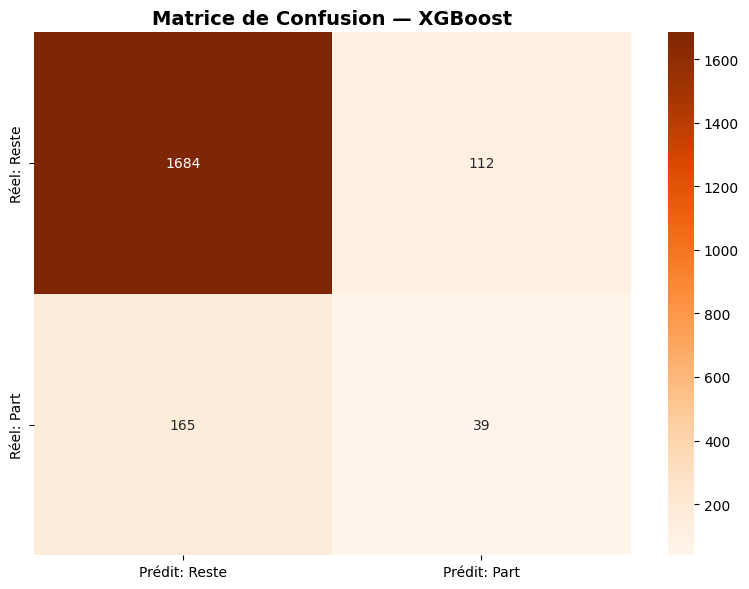


Analyse de la matrice :
   Vrais Négatifs  (TN) : 1684
   Faux Positifs   (FP) : 112
   Faux Négatifs   (FN) : 165 → churners manqués 
   Vrais Positifs  (TP) : 39 → churners détectés 

 Comparaison modèles précédents :
   LR  → FN=71,  TP=133
   RF  → FN=111, TP=93
   XGB → FN=165, TP=39


In [ ]:
# MATRICE DE CONFUSION

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nAnalyse de la matrice :")
print(f"   Vrais Négatifs  (TN) : {tn}")
print(f"   Faux Positifs   (FP) : {fp}")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués ")
print(f"   Vrais Positifs  (TP) : {tp} → churners détectés ")
print(f"\n Comparaison modèles précédents :")
print(f"   LR  → FN=71,  TP=133")
print(f"   RF  → FN=111, TP=93")
print(f"   XGB → FN={fn}, TP={tp}")

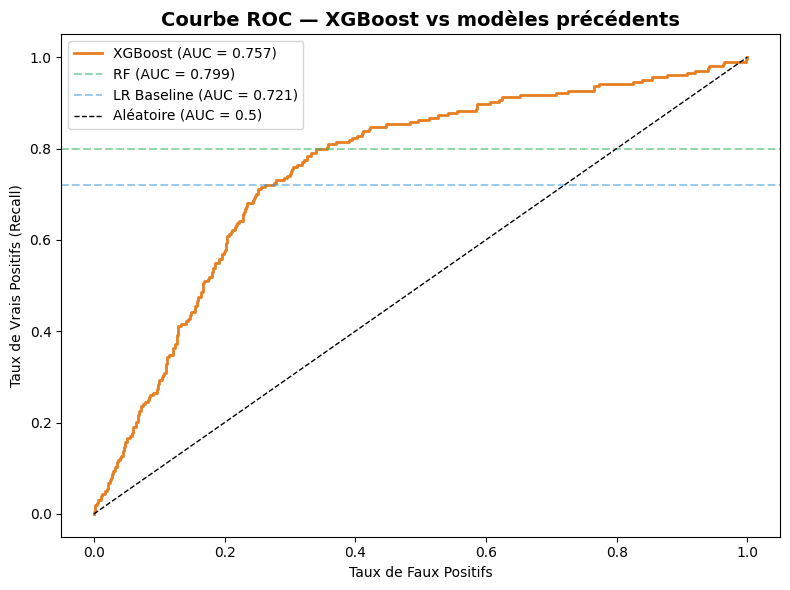

In [ ]:
# COURBE ROC — Comparaison tous les modèles

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
         label=f'XGBoost (AUC = {auc:.3f})')
plt.axhline(y=0.7993, color='#27ae60', linestyle='--',
            alpha=0.5, label='RF (AUC = 0.799)')
plt.axhline(y=0.7212, color='#3498db', linestyle='--',
            alpha=0.5, label='LR Baseline (AUC = 0.721)')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1,
         label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — XGBoost vs modèles précédents',
          fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_roc_curve.png', dpi=150)
plt.show()

## 🔍 Feature Importance XGBoost

XGBoost calcule l'importance différemment du Random Forest :
- **weight** : nombre de fois qu'une feature est utilisée
- **gain** : amélioration moyenne apportée par la feature
- **cover** : nombre d'échantillons couverts

On utilise `gain` car c'est la plus représentative 
de l'impact réel sur les prédictions.

On compare avec le Random Forest pour voir si les mêmes 
variables ressortent — cohérence = signe de robustesse.

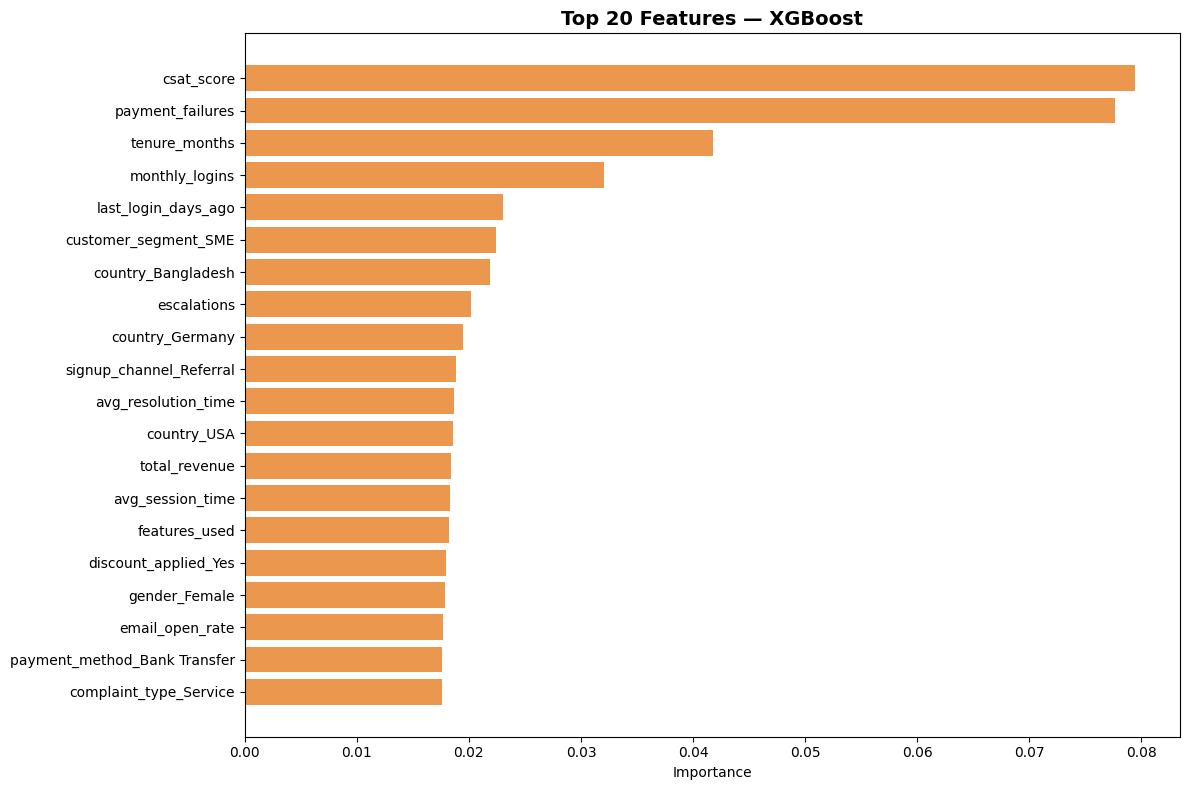


🔝 Top 10 features les plus importantes :
   1. csat_score                          : 0.0795
   2. payment_failures                    : 0.0777
   3. tenure_months                       : 0.0418
   4. monthly_logins                      : 0.0320
   5. last_login_days_ago                 : 0.0230
   6. customer_segment_SME                : 0.0224
   7. country_Bangladesh                  : 0.0219
   8. escalations                         : 0.0202
   9. country_Germany                     : 0.0195
   10. signup_channel_Referral             : 0.0188


In [ ]:
# FEATURE IMPORTANCE

importances = xgb_clf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.barh(range(20),
         importances[indices][::-1],
         color='#e67e22', alpha=0.8)
plt.yticks(range(20),
           [feature_names[i] for i in indices][::-1],
           fontsize=10)
plt.xlabel('Importance')
plt.title('Top 20 Features — XGBoost',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/xgb_feature_importance.png', dpi=150)
plt.show()

print("\n Top 10 features les plus importantes :")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]:35} : {importances[indices[i]]:.4f}")

## Tâche 2 — Régression du Revenu à Risque

On utilise XGBRegressor pour prédire le revenu à risque.

XGBoost est particulièrement adapté car :
- Il gère bien les distributions asymétriques
- La régularisation évite le surapprentissage
- Il optimise directement la fonction de perte

In [ ]:
# TÂCHE 2 — RÉGRESSION

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_reg.fit(X_train, y_train_reg)

y_pred_reg = xgb_reg.predict(X_test)
y_pred_reg = np.maximum(y_pred_reg, 0)

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print("Modèle de régression entraîné !")
print(f"\n Résultats — XGBoost Regression")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")
print(f"\n Comparaison modèles précédents :")
print(f"   Ridge → MAE=156.11€, R²=0.0533")
print(f"   RF    → MAE=145.39€, R²=0.0612")
print(f"   XGB   → MAE={mae:.2f}€,  R²={r2:.4f}")

Modèle de régression entraîné !

 Résultats — XGBoost Regression
   MAE  : 158.61 €
   RMSE : 386.03 €
   R²   : -0.0024

 Comparaison modèles précédents :
   Ridge → MAE=156.11€, R²=0.0533
   RF    → MAE=145.39€, R²=0.0612
   XGB   → MAE=158.61€,  R²=-0.0024


In [ ]:
# SAUVEGARDE

joblib.dump(xgb_clf, '../models/xgb_classification.pkl')
joblib.dump(xgb_reg, '../models/xgb_regression.pkl')

results_clf = {
    'model'    : 'XGBoost',
    'accuracy' : accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall'   : recall_score(y_test_clf, y_pred_clf),
    'f1'       : f1_score(y_test_clf, y_pred_clf),
    'roc_auc'  : roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'XGBoost Regression',
    'mae' : mae,
    'rmse': rmse,
    'r2'  : r2
}

pd.DataFrame([results_clf]).to_csv('../results/xgb_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/xgb_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\n Résumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

 Résumé Classification :
   accuracy   : 0.8615
   precision  : 0.2583
   recall     : 0.1912
   f1         : 0.2197
   roc_auc    : 0.7570


## Synthèse — XGBoost

### Comparaison avec les modèles précédents
| Métrique | LR | Random Forest | XGBoost |
|---|---|---|---|
| Accuracy | 0.6685 | 0.8355 | 0.8615 |
| Precision | 0.1834 | 0.2990 | 0.2583 |
| Recall | 0.6520 | 0.4559 | 0.1912 |
| F1-Score | 0.2863 | 0.3612 | 0.2197 |
| ROC-AUC | 0.7212 | 0.7993 | 0.7570 |

### Régression
| Métrique | Ridge | Random Forest | XGBoost |
|---|---|---|---|
| MAE | 156.11€ | 145.39€ | 158.61€ |
| R² | 0.0533 | 0.0612 | -0.0024 |

### Analyse des résultats

**Classification :**
XGBoost ne surpasse pas le Random Forest sur ce dataset.
Le Recall chute à 0.19 — on ne détecte que 19% des churners.
Cela s'explique par le fait que `scale_pos_weight` seul 
ne compense pas aussi bien que `class_weight='balanced'`.

**Régression :**
R² = -0.0024 — c'est pire que la baseline ! Un R² négatif
signifie que le modèle est moins bon que de prédire 
simplement la moyenne. Cela confirme que la tâche de 
régression est difficile avec ces données.

**Conclusion provisoire :**
Jusqu'ici le **Random Forest** donne le meilleur compromis
F1-Score / ROC-AUC. Le MLP pourrait changer la donne.

### Prochaine étape
MLP (Deep Learning) → réseau de neurones multicouches